In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
# Load the trained CatBoost pipeline
catboost_pipeline = joblib.load("../models/catboost_pipeline.pkl")

print(type(catboost_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [3]:
# Display all pipeline steps
print(catboost_pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('continuous', 'passthrough',
                                 ['tenure', 'MonthlyCharges', 'TotalCharges',
                                  'AvgMonthlySpend', 'TotalServices']),
                                ('binary', 'passthrough',
                                 ['SeniorCitizen', 'HasFamily']),
                                ('nominal',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('ordinal',
       

In [4]:
catboost_model = catboost_pipeline.named_steps["classifier"]

print(type(catboost_model))

<class 'catboost.core.CatBoostClassifier'>


In [5]:
preprocessor = catboost_pipeline.named_steps["preprocessor"]

print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [7]:
df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

print(df.shape)

df.head()

(7032, 27)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,AvgMonthlySpend,TotalServices,HasFamily,TenureGroup,SpendingGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,29.850000,1,0,New,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,55.573529,3,0,Established,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,54.075000,3,0,New,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,40.905556,3,0,Established,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,75.825000,1,0,New,Medium


In [8]:
X = df.drop(columns=["customerID", "Churn", "Churn_Binary"])
y = df["Churn_Binary"]

print(X.shape)
print(y.shape)

(7032, 24)
(7032,)


In [9]:
X_transformed = preprocessor.transform(X)

print(X_transformed.shape)

(7032, 50)


In [11]:
explainer = shap.TreeExplainer(catboost_model)

print(explainer)

In [12]:
# Compute SHAP values for the first 100 customers
shap_values = explainer.shap_values(X_transformed[:100])

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(100, 50)


In [13]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:10])

50
['continuous__tenure' 'continuous__MonthlyCharges'
 'continuous__TotalCharges' 'continuous__AvgMonthlySpend'
 'continuous__TotalServices' 'binary__SeniorCitizen' 'binary__HasFamily'
 'nominal__gender_Female' 'nominal__gender_Male' 'nominal__Partner_No']


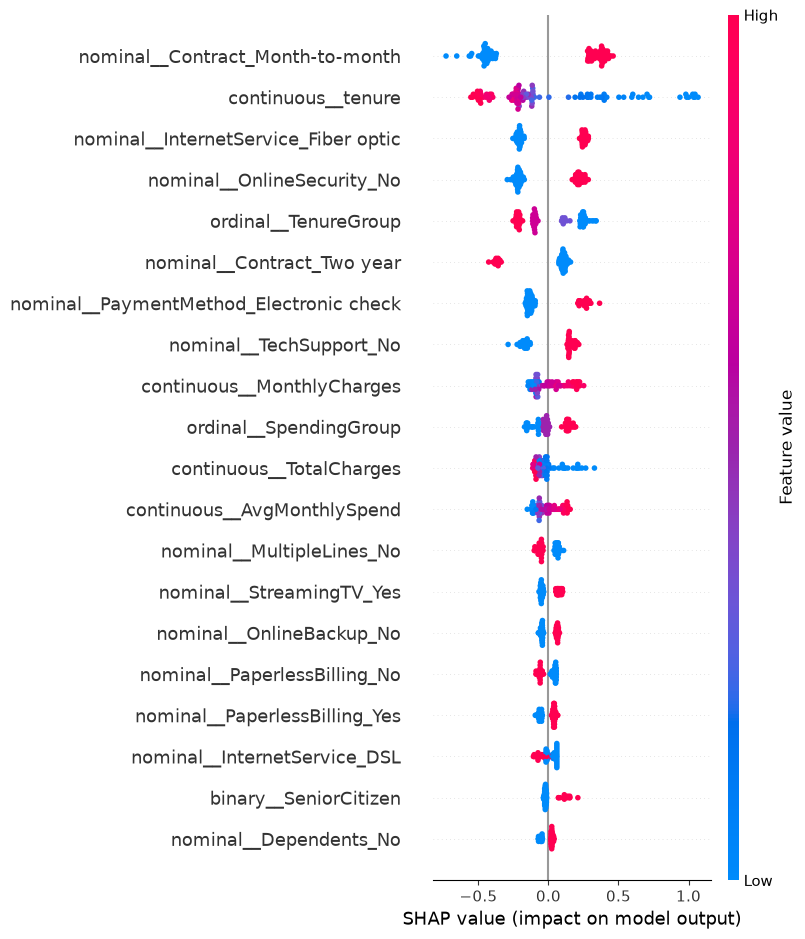

In [14]:
shap.summary_plot(
    shap_values,
    X_transformed[:100],
    feature_names=feature_names
)

In [15]:
clean_feature_names = [
    feature.replace("continuous__", "")
           .replace("nominal__", "")
           .replace("ordinal__", "")
           .replace("binary__", "")
    for feature in feature_names
]

print(clean_feature_names[:15])

['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices', 'SeniorCitizen', 'HasFamily', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes']


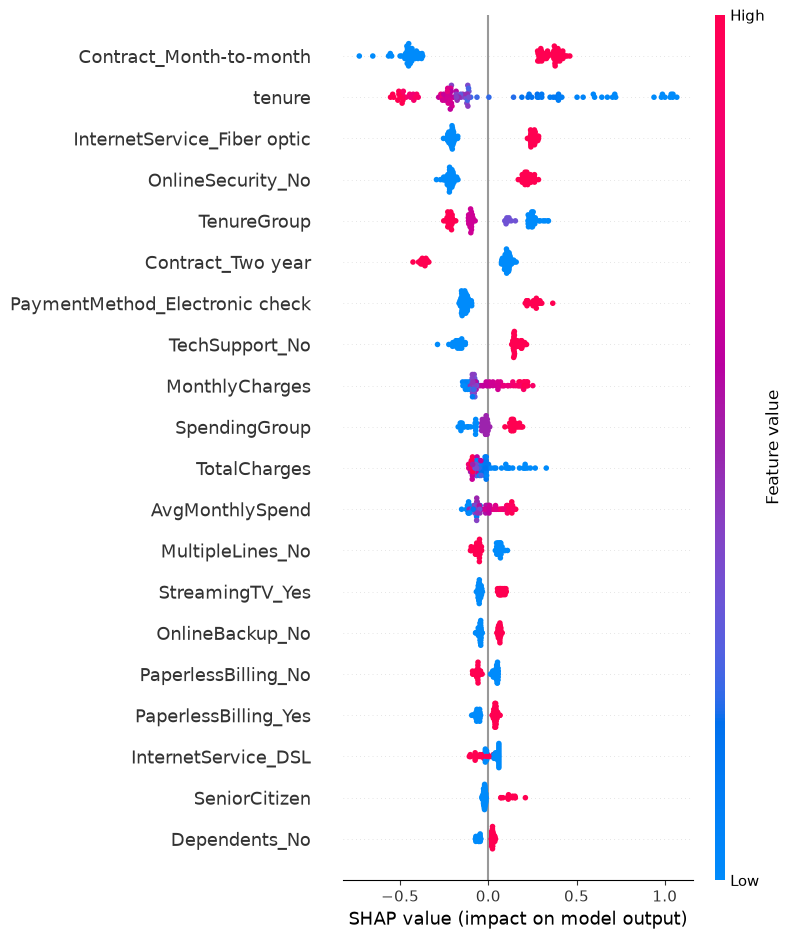

In [16]:
shap.summary_plot(
    shap_values,
    X_transformed[:100],
    feature_names=clean_feature_names
)

In [19]:
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=clean_feature_names
)

X_transformed_df.head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,TotalServices,SeniorCitizen,HasFamily,gender_Female,gender_Male,Partner_No,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup,SpendingGroup
0,1.0,29.85,29.85,29.850000,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,34.0,56.95,1889.50,55.573529,3.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
2,2.0,53.85,108.15,54.075000,3.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,45.0,42.30,1840.75,40.905556,3.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0
4,2.0,70.70,151.65,75.825000,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [23]:
# Compute SHAP values using the newer API
explanation = explainer(X_transformed_df.iloc[:100])

print(type(explanation))
print(explanation.shape)

<class 'shap._explanation.Explanation'>
(100, 50)


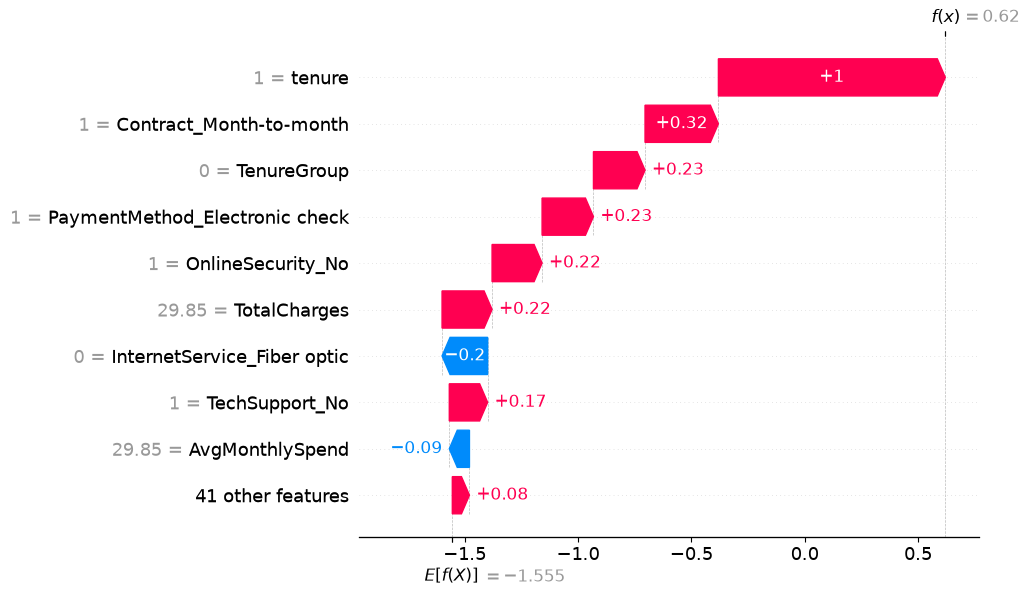

In [24]:
shap.plots.waterfall(explanation[0])

In [25]:
shap.initjs()

In [26]:
shap.force_plot(
    explanation.base_values[0],
    explanation.values[0],
    X_transformed_df.iloc[0]
)

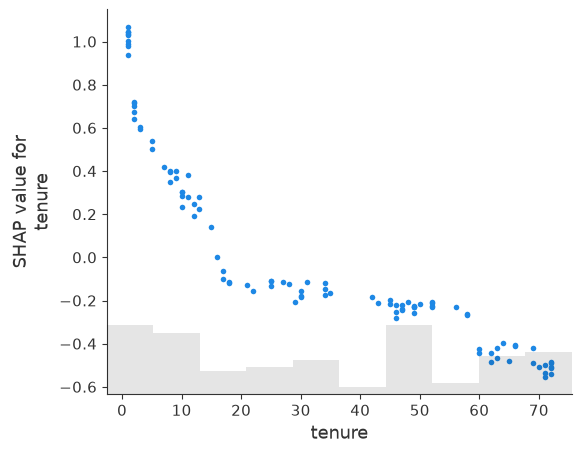

In [28]:
shap.plots.scatter(
    explanation[:, "tenure"]
)

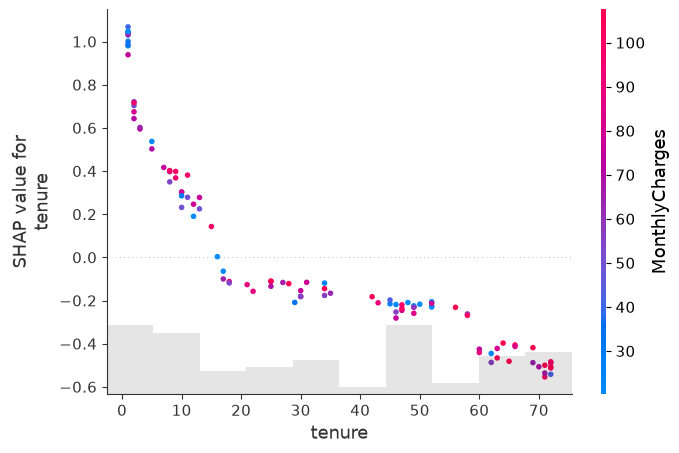

In [30]:
shap.plots.scatter(
    explanation[:, "tenure"],
    color=explanation[:, "MonthlyCharges"]
)

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

In [5]:
X = df.drop(columns=["customerID", "Churn", "Churn_Binary"])

In [6]:
X.iloc[0].to_dict()

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'No',
 'tenure': 1,
 'PhoneService': 'No',
 'MultipleLines': 'No phone service',
 'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'No',
 'StreamingTV': 'No',
 'StreamingMovies': 'No',
 'Contract': 'Month-to-month',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Electronic check',
 'MonthlyCharges': 29.85,
 'TotalCharges': 29.85,
 'AvgMonthlySpend': 29.85,
 'TotalServices': 1,
 'HasFamily': 0,
 'TenureGroup': 'New',
 'SpendingGroup': 'Low'}

In [7]:
import pandas as pd

_, bins = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    retbins=True,
    duplicates="drop"
)

print(bins)

[ 18.25  50.4   84.   118.75]
